In [3]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [5]:
qc = QuantumCircuit(3, 2)


In [6]:
qc.h(0)

In [7]:
qc.cx(0, 1)
qc.h(0)

In [8]:
qc.measure(0, 0)
qc.measure(1, 1)


In [9]:
print(qc.draw())


     ┌───┐     ┌───┐┌─┐
q_0: ┤ H ├──■──┤ H ├┤M├
     └───┘┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├─┤M├──╫─
          └───┘ └╥┘  ║ 
q_2: ────────────╫───╫─
                 ║   ║ 
c: 2/════════════╩═══╩═
                 1   0 


In [10]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()

print(counts)

{'10': 244, '00': 236, '01': 264, '11': 256}


In [11]:
qc = QuantumCircuit(3, 3)


In [12]:
# Prepare the state to teleport
qc.h(0)

# Create Bell pair between q1 and q2
qc.h(1)
qc.cx(1, 2)

In [13]:
print(qc.draw())


     ┌───┐     
q_0: ┤ H ├─────
     ├───┤     
q_1: ┤ H ├──■──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
          └───┘
c: 3/══════════
               


In [14]:
qc.cx(0, 1)
qc.h(0)


In [15]:
print(qc.draw())

     ┌───┐          ┌───┐
q_0: ┤ H ├───────■──┤ H ├
     ├───┤     ┌─┴─┐└───┘
q_1: ┤ H ├──■──┤ X ├─────
     └───┘┌─┴─┐└───┘     
q_2: ─────┤ X ├──────────
          └───┘          
c: 3/════════════════════
                         


In [16]:
qc.measure(0, 0)
qc.measure(1, 1)

In [17]:
print(qc.draw())

     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤     ┌─┴─┐└┬─┬┘└╥┘
q_1: ┤ H ├──■──┤ X ├─┤M├──╫─
     └───┘┌─┴─┐└───┘ └╥┘  ║ 
q_2: ─────┤ X ├───────╫───╫─
          └───┘       ║   ║ 
c: 3/═════════════════╩═══╩═
                      1   0 


In [21]:
with qc.if_test((qc.clbits[1], True)):
    qc.x(2)

In [22]:
with qc.if_test((qc.clbits[0], True)):
    qc.z(2)

In [23]:
qc.measure(2, 2)

In [24]:
print(qc.draw())

     ┌───┐          ┌───┐     ┌─┐                                          »
q_0: ┤ H ├───────■──┤ H ├─────┤M├──────────────────────────────────────────»
     ├───┤     ┌─┴─┐└┬─┬┘     └╥┘                                          »
q_1: ┤ H ├──■──┤ X ├─┤M├───────╫───────────────────────────────────────────»
     └───┘┌─┴─┐├───┤ └╥┘ ┌───┐ ║ ┌───┐  ┌──────  ┌───┐ ───────┐   ┌──────  »
q_2: ─────┤ X ├┤ X ├──╫──┤ X ├─╫─┤ X ├──┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─»
          └───┘└───┘  ║  └───┘ ║ └───┘  └──╥───  └───┘ ───────┘   └──╥───  »
                      ║        ║      ┌────╨────┐               ┌────╨────┐»
c: 3/═════════════════╩════════╩══════╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞»
                      1        0      └─────────┘               └─────────┘»
«                       
«q_0: ──────────────────
«                       
«q_1: ──────────────────
«     ┌───┐ ───────┐ ┌─┐
«q_2: ┤ Z ├  End-0 ├─┤M├
«     └───┘ ───────┘ └╥┘
«c: 3/════════════════╩═
«                     2 


In [25]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 3)

# 1. State to teleport: |+>
qc.h(0)

# 2. Create Bell pair
qc.h(1)
qc.cx(1, 2)

# 3. Alice's operations
qc.cx(0, 1)
qc.h(0)

# 4. Alice measures
qc.measure(0, 0)
qc.measure(1, 1)

# 5. Bob's conditional corrections
with qc.if_test((qc.clbits[1], True)):
    qc.x(2)

with qc.if_test((qc.clbits[0], True)):
    qc.z(2)

# 6. Bob measures
qc.measure(2, 2)

print(qc.draw())

     ┌───┐          ┌───┐┌─┐                                                   »
q_0: ┤ H ├───────■──┤ H ├┤M├───────────────────────────────────────────────────»
     ├───┤     ┌─┴─┐└┬─┬┘└╥┘                                                   »
q_1: ┤ H ├──■──┤ X ├─┤M├──╫────────────────────────────────────────────────────»
     └───┘┌─┴─┐└───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐»
q_2: ─────┤ X ├───────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├»
          └───┘       ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘»
                      ║   ║ ┌────╨────┐               ┌────╨────┐              »
c: 3/═════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞══════════════»
                      1   0 └─────────┘               └─────────┘              »
«         
«q_0: ────
«         
«q_1: ────
«      ┌─┐
«q_2: ─┤M├
«      └╥┘
«c: 3/══╩═
«       2 


In [26]:
simulator = AerSimulator()

result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()

print(counts)

{'100': 116, '110': 112, '101': 133, '001': 124, '000': 128, '010': 135, '011': 130, '111': 122}


In [27]:
qc_test = QuantumCircuit(3, 3)

# q0 = |0> already, so no gate needed

# Create Bell pair
qc_test.h(1)
qc_test.cx(1, 2)

# Alice's operations
qc_test.cx(0, 1)
qc_test.h(0)

# Alice measures q0 and q1
qc_test.measure(0, 0)
qc_test.measure(1, 1)

# Bob's corrections
with qc_test.if_test((qc_test.clbits[1], True)):
    qc_test.x(2)

with qc_test.if_test((qc_test.clbits[0], True)):
    qc_test.z(2)

# Bob measures q2
qc_test.measure(2, 2)

print(qc_test.draw())

                    ┌───┐┌─┐                                                   »
q_0: ────────────■──┤ H ├┤M├───────────────────────────────────────────────────»
     ┌───┐     ┌─┴─┐└┬─┬┘└╥┘                                                   »
q_1: ┤ H ├──■──┤ X ├─┤M├──╫────────────────────────────────────────────────────»
     └───┘┌─┴─┐└───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐»
q_2: ─────┤ X ├───────╫───╫───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├»
          └───┘       ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘»
                      ║   ║ ┌────╨────┐               ┌────╨────┐              »
c: 3/═════════════════╩═══╩═╡ c_1=0x1 ╞═══════════════╡ c_0=0x1 ╞══════════════»
                      1   0 └─────────┘               └─────────┘              »
«         
«q_0: ────
«         
«q_1: ────
«      ┌─┐
«q_2: ─┤M├
«      └╥┘
«c: 3/══╩═
«       2 


In [28]:
simulator = AerSimulator()

result = simulator.run(qc_test, shots=1000).result()

counts = result.get_counts()

print(counts)

{'001': 230, '011': 268, '000': 243, '010': 259}


In [29]:
from qiskit_aer.noise import NoiseModel, pauli_error

noise_model = NoiseModel()

bit_flip = pauli_error([
    ('X', 0.1),
    ('I', 0.9)
])

noise_model.add_all_qubit_quantum_error(bit_flip, ['h', 'cx'])

NoiseError: '1 qubit QuantumError cannot be applied to 2 qubit instruction "cx".'

In [30]:
from qiskit_aer.noise import NoiseModel, pauli_error

noise_model = NoiseModel()

# 1-qubit bit-flip error
bit_flip_1q = pauli_error([
    ('X', 0.1),
    ('I', 0.9)
])

# 2-qubit bit-flip error for CNOT
bit_flip_2q = pauli_error([
    ('XI', 0.1),
    ('II', 0.9)
])

# Apply 1-qubit noise to H gates
noise_model.add_all_qubit_quantum_error(
    bit_flip_1q, ['h']
)

# Apply 2-qubit noise to CNOT gates
noise_model.add_all_qubit_quantum_error(
    bit_flip_2q, ['cx']
)

print("Noise model created!")

Noise model created!


In [31]:
noisy_result = simulator.run(
    qc_test,
    shots=1000,
    noise_model=noise_model
).result()

noisy_counts = noisy_result.get_counts()

print(noisy_counts)

{'100': 43, '101': 47, '110': 39, '111': 40, '011': 214, '001': 209, '000': 192, '010': 216}


In [32]:
noise_model_0 = NoiseModel()

bit_flip_1q_0 = pauli_error([
    ('X', 0.0),
    ('I', 1.0)
])

bit_flip_2q_0 = pauli_error([
    ('XI', 0.0),
    ('II', 1.0)
])

noise_model_0.add_all_qubit_quantum_error(bit_flip_1q_0, ['h'])
noise_model_0.add_all_qubit_quantum_error(bit_flip_2q_0, ['cx'])

In [33]:
result_0 = simulator.run(
    qc_test,
    shots=1000,
    noise_model=noise_model_0
).result()

counts_0 = result_0.get_counts()
print(counts_0)

{'010': 241, '000': 246, '011': 260, '001': 253}


In [37]:
noise_levels = np.arange(0, 0.21, 0.02)

success_rates = []

for p in noise_levels:

    # Create noise model
    noise_model = NoiseModel()

    bit_flip_1q = pauli_error([
        ('X', p),
        ('I', 1-p)
    ])

    bit_flip_2q = pauli_error([
        ('XI', p),
        ('II', 1-p)
    ])

    noise_model.add_all_qubit_quantum_error(
        bit_flip_1q, ['h']
    )

    noise_model.add_all_qubit_quantum_error(
        bit_flip_2q, ['cx']
    )

    # Run simulation
    result = simulator.run(
        qc_test,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts = result.get_counts()

    # Count shots where Bob measured 0
    correct = sum(
        count for bitstring, count in counts.items()
        if bitstring[0] == '0'
    )

    success_rate = correct / 1000
    success_rates.append(success_rate)
print(noisy_counts)
print("Noise levels:", noise_levels)
print("Success rates:", success_rates)

{'100': 43, '101': 47, '110': 39, '111': 40, '011': 214, '001': 209, '000': 192, '010': 216}
Noise levels: [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2 ]
Success rates: [1.0, 0.956, 0.915, 0.876, 0.853, 0.804, 0.786, 0.79, 0.7, 0.692, 0.676]


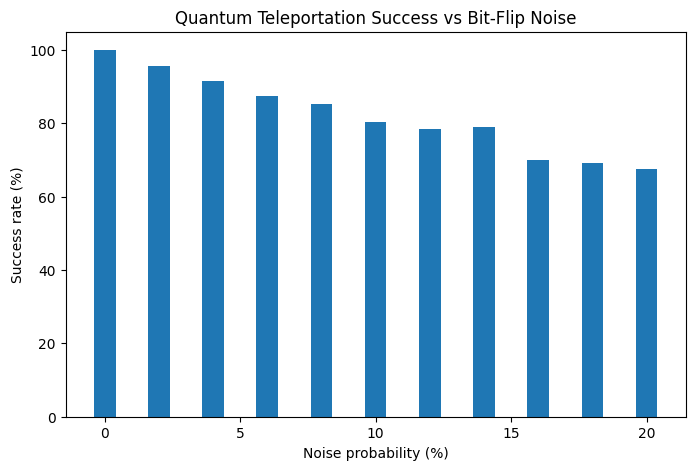

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(noise_levels * 100, np.array(success_rates) * 100)

plt.xlabel("Noise probability (%)")
plt.ylabel("Success rate (%)")
plt.title("Quantum Teleportation Success vs Bit-Flip Noise")

plt.show()

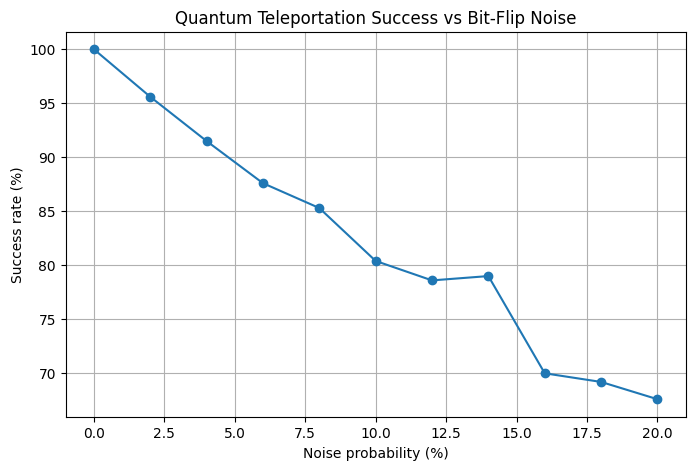

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(noise_levels * 100, np.array(success_rates) * 100, marker='o')

plt.xlabel("Noise probability (%)")
plt.ylabel("Success rate (%)")
plt.title("Quantum Teleportation Success vs Bit-Flip Noise")

plt.grid(True)
plt.show()

In [40]:
# Noise levels: 0% to 20% in steps of 2%
noise_levels = np.arange(0, 0.21, 0.02)

success_rates = []
all_counts = []

for p in noise_levels:

    # -------------------------
    # 1. Create noise model
    # -------------------------
    noise_model = NoiseModel()

    bit_flip_1q = pauli_error([
        ('X', p),
        ('I', 1 - p)
    ])

    bit_flip_2q = pauli_error([
        ('XI', p),
        ('II', 1 - p)
    ])

    noise_model.add_all_qubit_quantum_error(
        bit_flip_1q, ['h']
    )

    noise_model.add_all_qubit_quantum_error(
        bit_flip_2q, ['cx']
    )

    # -------------------------
    # 2. Run simulation
    # -------------------------
    result = simulator.run(
        qc_test,
        shots=1000,
        noise_model=noise_model
    ).result()

    counts = result.get_counts()

    # Save complete measurement distribution
    all_counts.append(counts)

    # -------------------------
    # 3. Calculate success rate
    # -------------------------
    correct = sum(
        count
        for bitstring, count in counts.items()
        if bitstring[0] == '0'
    )

    success_rate = correct / 1000

    success_rates.append(success_rate)


# Print results
print("Noise levels:")
print(noise_levels)

print("\nSuccess rates:")
print(success_rates)

print("\nMeasurement counts at each noise level:")
for noise, counts in zip(noise_levels, all_counts):
    print(f"\nNoise = {noise*100:.0f}%")
    print(counts)

Noise levels:
[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2 ]

Success rates:
[1.0, 0.962, 0.921, 0.879, 0.871, 0.832, 0.805, 0.766, 0.725, 0.711, 0.686]

Measurement counts at each noise level:

Noise = 0%
{'001': 236, '011': 236, '000': 275, '010': 253}

Noise = 2%
{'100': 9, '101': 5, '110': 12, '001': 256, '111': 12, '011': 266, '000': 234, '010': 206}

Noise = 4%
{'101': 21, '100': 17, '111': 18, '011': 238, '110': 23, '001': 223, '000': 231, '010': 229}

Noise = 6%
{'110': 32, '100': 25, '000': 197, '010': 240, '111': 27, '011': 227, '001': 215, '101': 37}

Noise = 8%
{'110': 29, '100': 37, '101': 27, '001': 219, '111': 36, '011': 218, '000': 228, '010': 206}

Noise = 10%
{'110': 55, '101': 45, '100': 33, '001': 234, '111': 35, '011': 191, '000': 205, '010': 202}

Noise = 12%
{'101': 53, '110': 46, '100': 44, '111': 52, '011': 213, '001': 203, '010': 192, '000': 197}

Noise = 14%
{'100': 54, '001': 221, '010': 165, '000': 187, '101': 60, '111': 69, '011': 193, '110': 51}

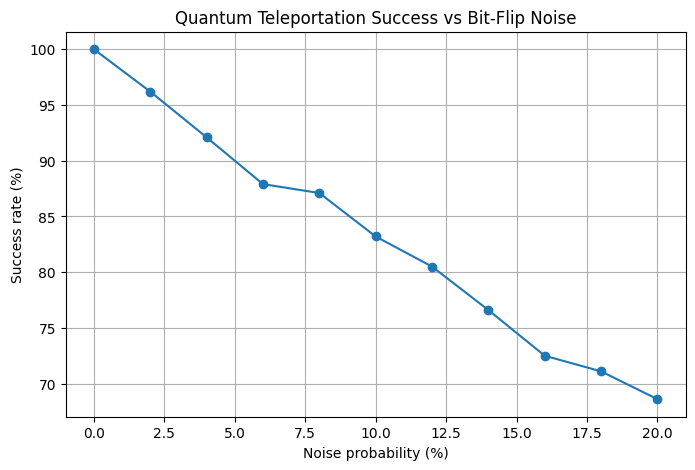

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    noise_levels * 100,
    np.array(success_rates) * 100,
    marker='o'
)

plt.xlabel("Noise probability (%)")
plt.ylabel("Success rate (%)")
plt.title("Quantum Teleportation Success vs Bit-Flip Noise")

plt.grid(True)
plt.show()

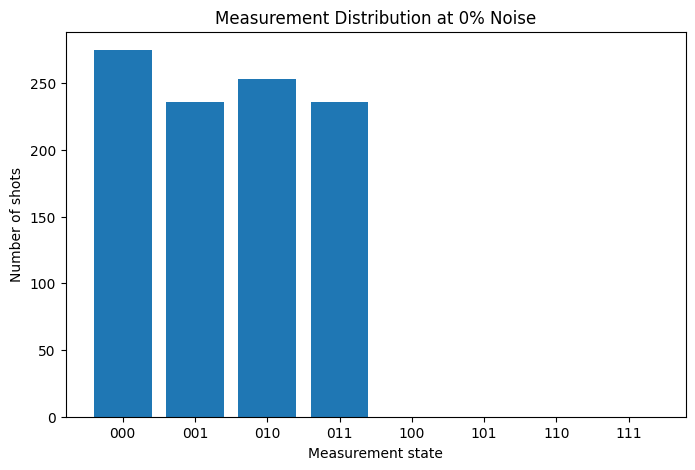

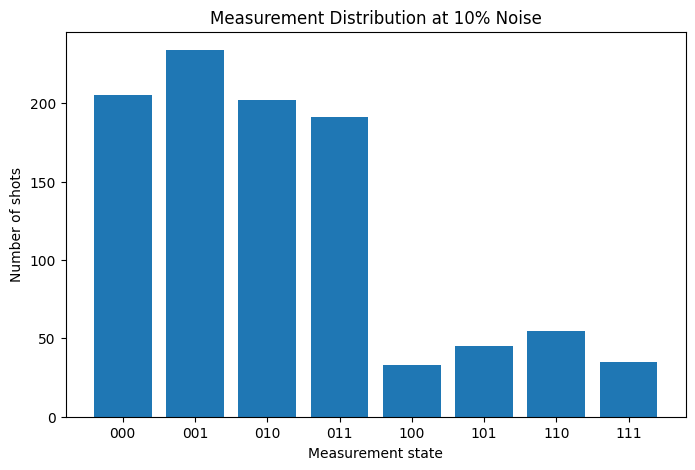

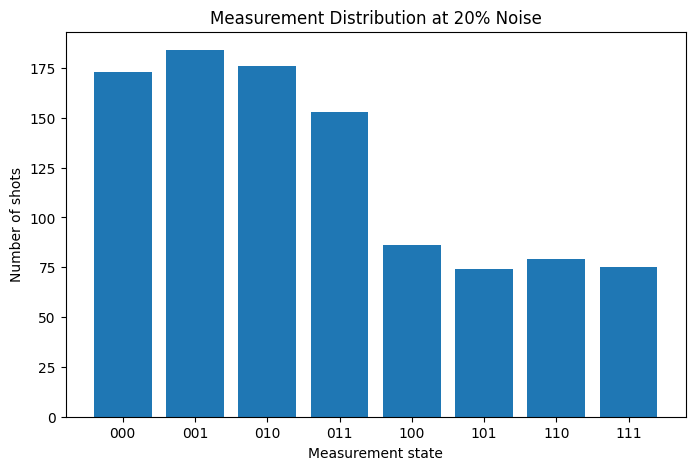

In [42]:
selected_indices = [0, 5, 10]

for i in selected_indices:

    counts = all_counts[i]

    # Make sure all 8 states are included
    states = ['000', '001', '010', '011',
              '100', '101', '110', '111']

    shots = [counts.get(state, 0) for state in states]

    plt.figure(figsize=(8, 5))

    plt.bar(states, shots)

    plt.xlabel("Measurement state")
    plt.ylabel("Number of shots")
    plt.title(
        f"Measurement Distribution at "
        f"{noise_levels[i]*100:.0f}% Noise"
    )

    plt.show()